# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob as globmod
from IPython.display import display
from helpers import (
    # HRS file readers
    read_hrs1, read_hrs2, find_hrs_files,
    # HRS signal helpers
    detect_stim_onset, get_trial_window,
    # HRS data classes
    EmgCharHeader, EmgCharTrial, EmgDataBlock, MhRecHeader, MhRecTrial,
    # HRS constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    TRIAL_RECORD_SAMPLES, MS_PER_SAMPLE,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    BLOCK_EMG_DATA, BLOCK_EMG_CHAR_TRIAL, BLOCK_MH_TRIAL,
)

print("Binary reader utilities loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")


Binary reader utilities loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 1.0 V | end < 0.6 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [49]:
# ---- Set your recording directory here ----
recording_dir = "TEST2"

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
print(f"  HRS2 file: {os.path.basename(hrs2_path)}")


Recording directory: TEST2
  HRS1 file: TEST2_20260316T164235.hrs1
  HRS2 file: TEST2_20260316T164509.hrs2


In [50]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)

print(f"=== HRS1 Header ===")
print(f"  File:               {os.path.basename(hrs1_path)}")
print(f"  File version:       {hrs1_header.file_version}")
print(f"  Subject ID:         {hrs1_header.subject_id}")
print(f"  Session datetime:   {hrs1_header.session_datetime}")
print(f"  Stage name:         {hrs1_header.stage_name}")
print(f"  Stage description:  {hrs1_header.stage_description}")
print(f"  Stage type:         {hrs1_header.stage_type}")
print(f"  Trial init uV min:  {hrs1_header.trial_initiation_uv_min}")
print(f"  Trial init uV max:  {hrs1_header.trial_initiation_uv_max}")
print(f"  Trial init phase min ms: {hrs1_header.trial_initiation_phase_min_ms}")
print(f"  Trial init phase max ms: {hrs1_header.trial_initiation_phase_max_ms}")
print(f"  Bin duration ms:    {hrs1_header.bin_duration_ms}")
print(f"\n  Trials found:       {len(hrs1_trials)}")
print(f"  EMG data blocks:    {len(hrs1_emg_blocks)}")

if len(hrs1_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs1_trials[0]
    print(f"  End datetime:       {t0.trial_end_datetime}")
    print(f"  Start index:        {t0.trial_start_index}")
    print(f"  Grand mean:         {t0.grand_mean:.4f}")
    print(f"  Bins count:         {len(t0.bins)}")
    print(f"  Monitored signal N: {len(t0.monitored_signal)}")

if len(hrs1_emg_blocks) > 0:
    b0 = hrs1_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:      {b0.channel_names}")
    print(f"  Raw channels:       {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
    print(f"  Diff samples:       {len(b0.diff)}")
    print(f"  Filtered samples:   {len(b0.filtered)}")
    print(f"  Abs samples:        {len(b0.abs_val)}")

=== HRS1 Header ===
  File:               TEST2_20260316T164235.hrs1
  File version:       0
  Subject ID:         TEST2
  Session datetime:   2026-03-16 16:42:35.959056
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  5.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50

  Trials found:       59
  EMG data blocks:    5954

=== First Trial ===
  End datetime:       2026-03-16 16:42:38.582307
  Start index:        0
  Grand mean:         83.8065
  Bins count:         53
  Monitored signal N: 13250

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1']
  Raw channels:       3 x 122 samples
  Diff samples:       122
  Filtered samples:   122
  Abs samples:        122


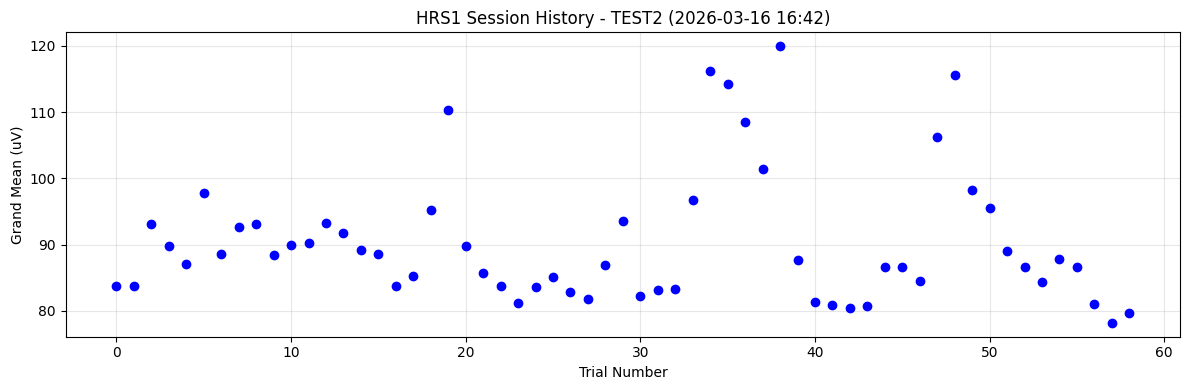

Grand mean range: [78.17, 119.96] uV
Overall mean of grand means: 90.39 uV


In [51]:
# ---- Plot HRS1: Trial Grand Means (Session History) ----
grand_means = [t.grand_mean for t in hrs1_trials]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(grand_means)), grand_means, 'o', color='blue', markersize=6)
ax.set_xlabel('Trial Number')
ax.set_ylabel('Grand Mean (uV)')
ax.set_title(f'HRS1 Session History - {hrs1_header.subject_id} ({hrs1_header.session_datetime:%Y-%m-%d %H:%M})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grand mean range: [{min(grand_means):.2f}, {max(grand_means):.2f}] uV")
print(f"Overall mean of grand means: {np.mean(grand_means):.2f} uV")

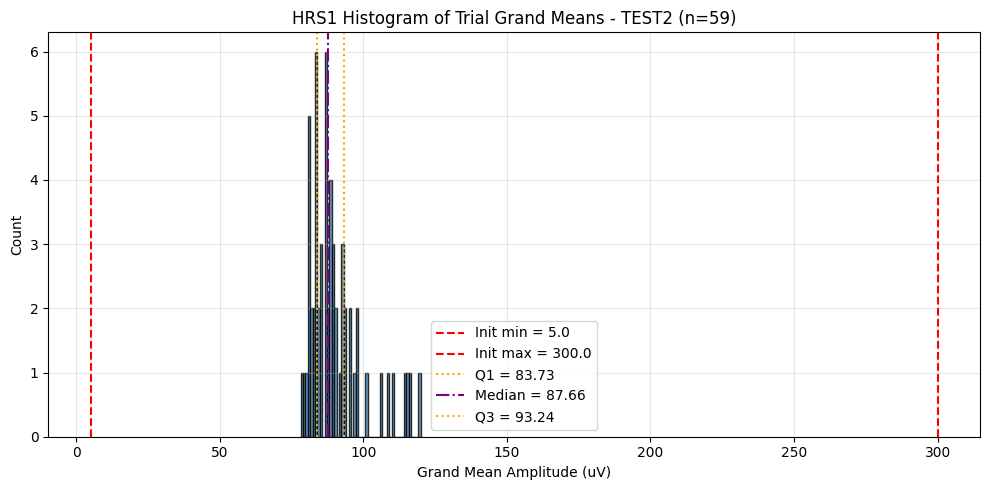

Stats: min=78.17, Q1=83.73, median=87.66, Q3=93.24, max=119.96, std=9.80


In [52]:
# ---- Plot HRS1: Histogram of Grand Means ----
gm = np.array(grand_means)

fig, ax = plt.subplots(figsize=(10, 5))
hist_vals, hist_edges, _ = ax.hist(gm, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(hrs1_header.trial_initiation_uv_min, color='red', linestyle='--', linewidth=1.5, label=f'Init min = {hrs1_header.trial_initiation_uv_min}')
ax.axvline(hrs1_header.trial_initiation_uv_max, color='red', linestyle='--', linewidth=1.5, label=f'Init max = {hrs1_header.trial_initiation_uv_max}')

q25, q50, q75 = np.percentile(gm, [25, 50, 75])
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 = {q25:.2f}')
ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median = {q50:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 = {q75:.2f}')

ax.set_xlabel('Grand Mean Amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title(f'HRS1 Histogram of Trial Grand Means - {hrs1_header.subject_id} (n={len(gm)})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stats: min={gm.min():.2f}, Q1={q25:.2f}, median={q50:.2f}, Q3={q75:.2f}, max={gm.max():.2f}, std={gm.std():.2f}")

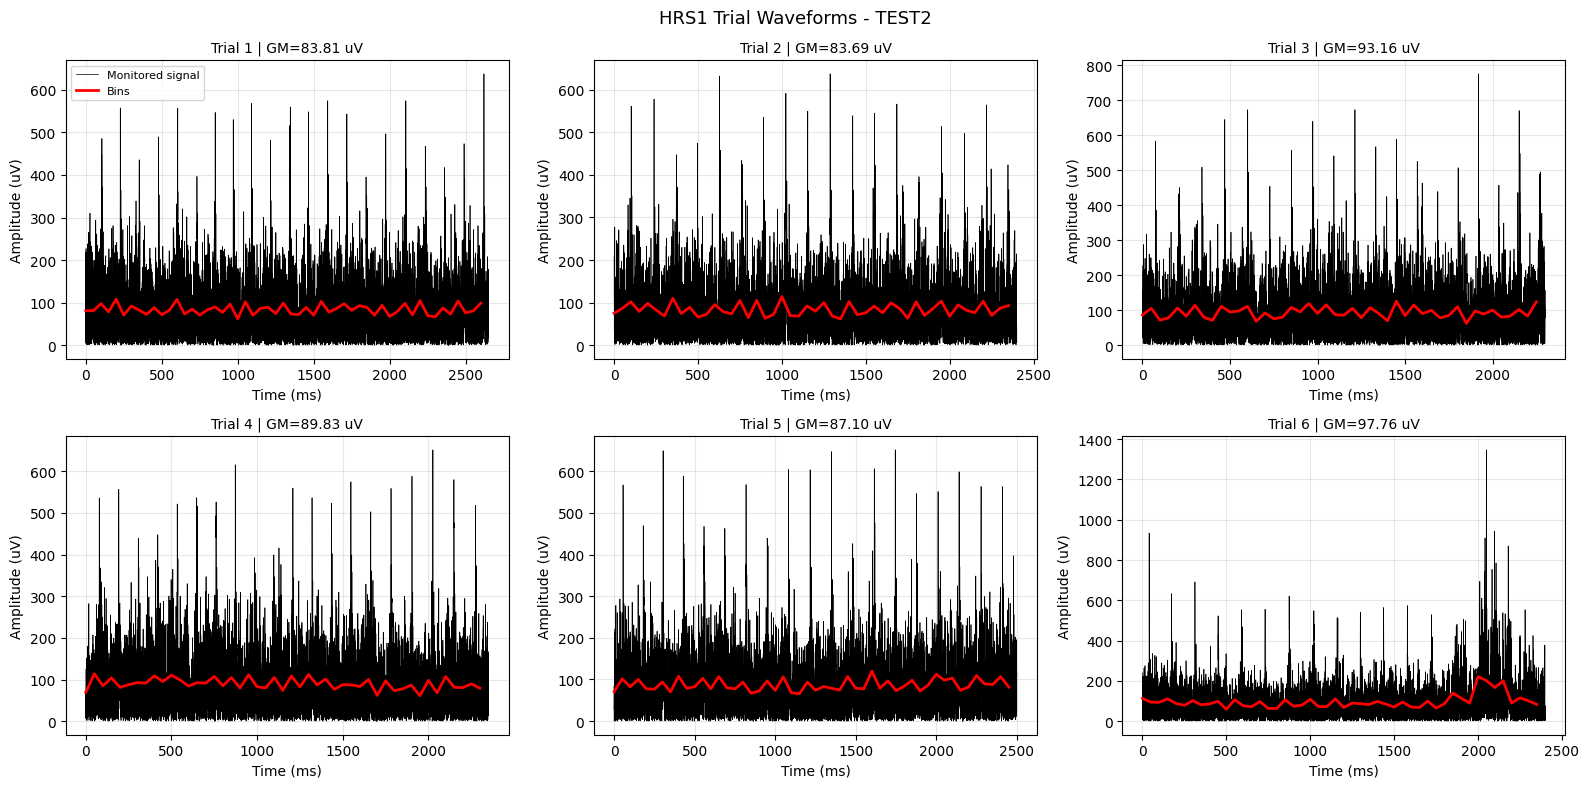

In [53]:
# ---- Plot HRS1: Individual Trial Waveforms (first 6 trials) ----
SAMPLE_RATE = 5000.0  # Hz (from the app)
n_show = min(6, len(hrs1_trials))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]
    trial = hrs1_trials[i]
    sig = np.array(trial.monitored_signal)
    bins_arr = np.array(trial.bins)
    bin_sample_count = int((SAMPLE_RATE / 1000) * hrs1_header.bin_duration_ms)

    # Time axis in ms
    t_ms = np.arange(len(sig)) / SAMPLE_RATE * 1000.0

    # Plot monitored signal (abs EMG)
    ax.plot(t_ms, sig, color='black', linewidth=0.5, label='Monitored signal')

    # Plot bins
    bin_x = np.arange(len(bins_arr)) * hrs1_header.bin_duration_ms
    ax.plot(bin_x, bins_arr, color='red', linewidth=2, label='Bins')

    ax.set_title(f'Trial {i+1} | GM={trial.grand_mean:.2f} uV', fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (uV)')
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'HRS1 Trial Waveforms - {hrs1_header.subject_id}', fontsize=13)
plt.tight_layout()
plt.show()

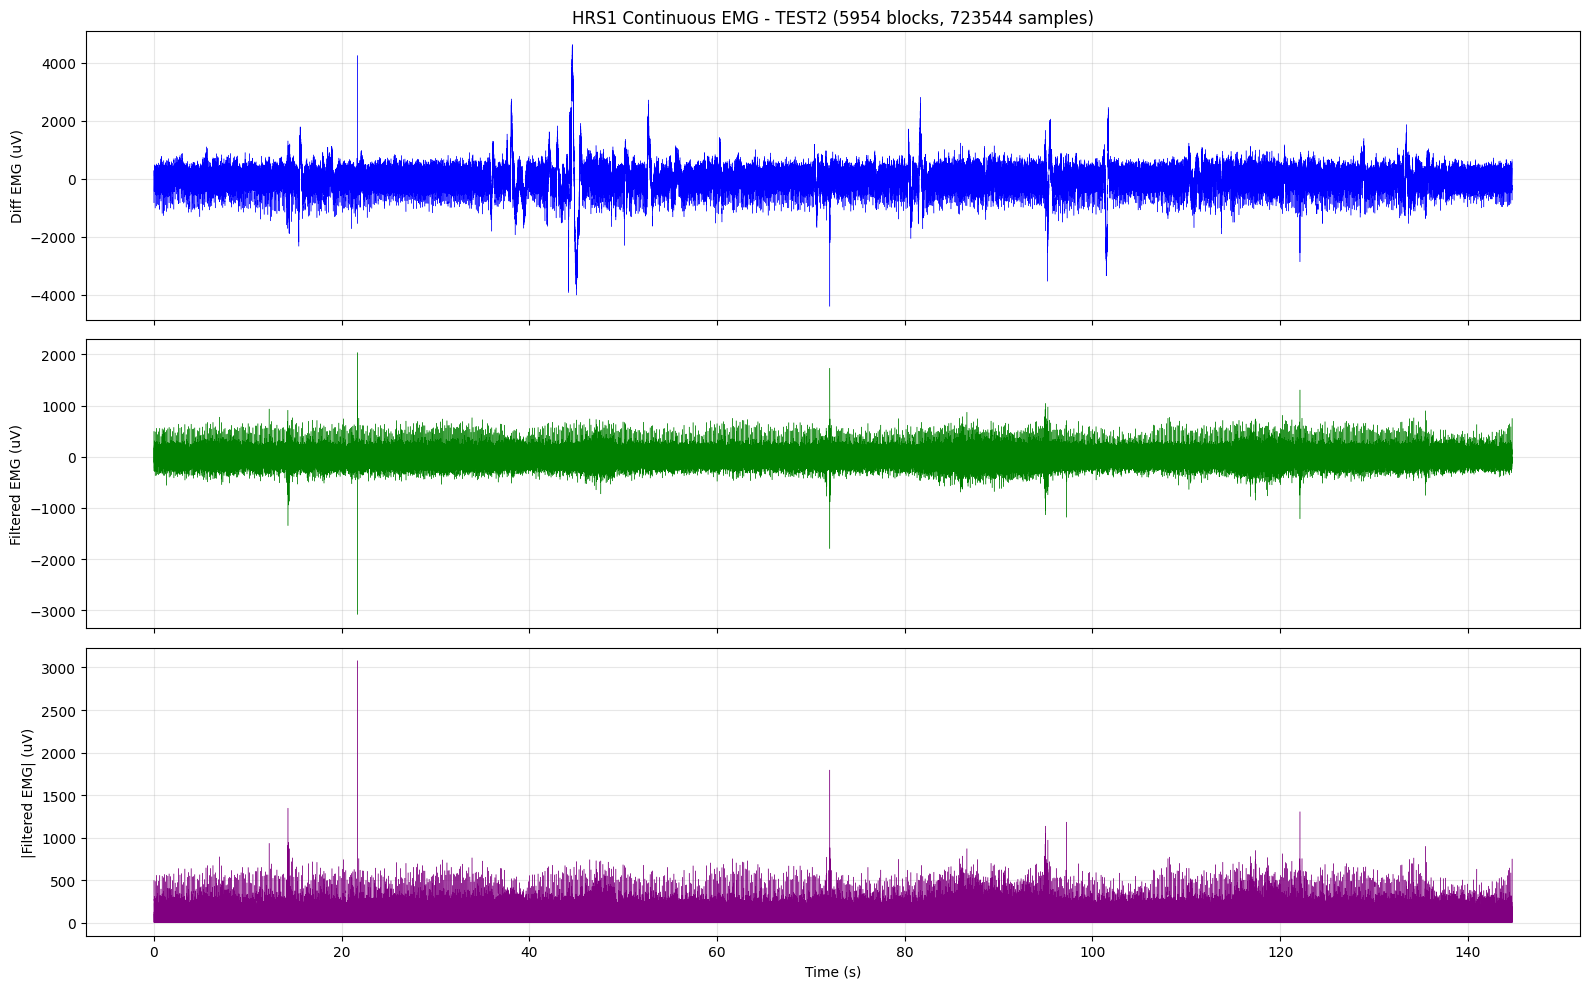

Total continuous samples: 723544, Duration: 144.7 s
Channel names: ['CH10', 'CH12', 'ADC1']


In [54]:
# ---- Plot HRS1: Continuous EMG Data (diff, filtered, abs) ----
# Concatenate all EMG blocks to reconstruct the session timeline

if len(hrs1_emg_blocks) > 0:
    all_diff = np.concatenate([b.diff for b in hrs1_emg_blocks])
    all_filt = np.concatenate([b.filtered for b in hrs1_emg_blocks])
    all_abs  = np.concatenate([b.abs_val for b in hrs1_emg_blocks])
    all_ts   = np.array([b.ts_open_ephys_sent for b in hrs1_emg_blocks])

    # Build a sample-level time axis in seconds (relative to session start)
    t_samples = np.arange(len(all_diff)) / SAMPLE_RATE

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_samples, all_diff, color='blue', linewidth=0.3)
    axes[0].set_ylabel('Diff EMG (uV)')
    axes[0].set_title(f'HRS1 Continuous EMG - {hrs1_header.subject_id} ({len(hrs1_emg_blocks)} blocks, {len(all_diff)} samples)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_samples, all_filt, color='green', linewidth=0.3)
    axes[1].set_ylabel('Filtered EMG (uV)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_samples, all_abs, color='purple', linewidth=0.3)
    axes[2].set_ylabel('|Filtered EMG| (uV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Total continuous samples: {len(all_diff)}, Duration: {t_samples[-1]:.1f} s")
    if len(hrs1_emg_blocks[0].channel_names) > 0:
        print(f"Channel names: {hrs1_emg_blocks[0].channel_names}")
else:
    print("No EMG data blocks found in this HRS1 file.")

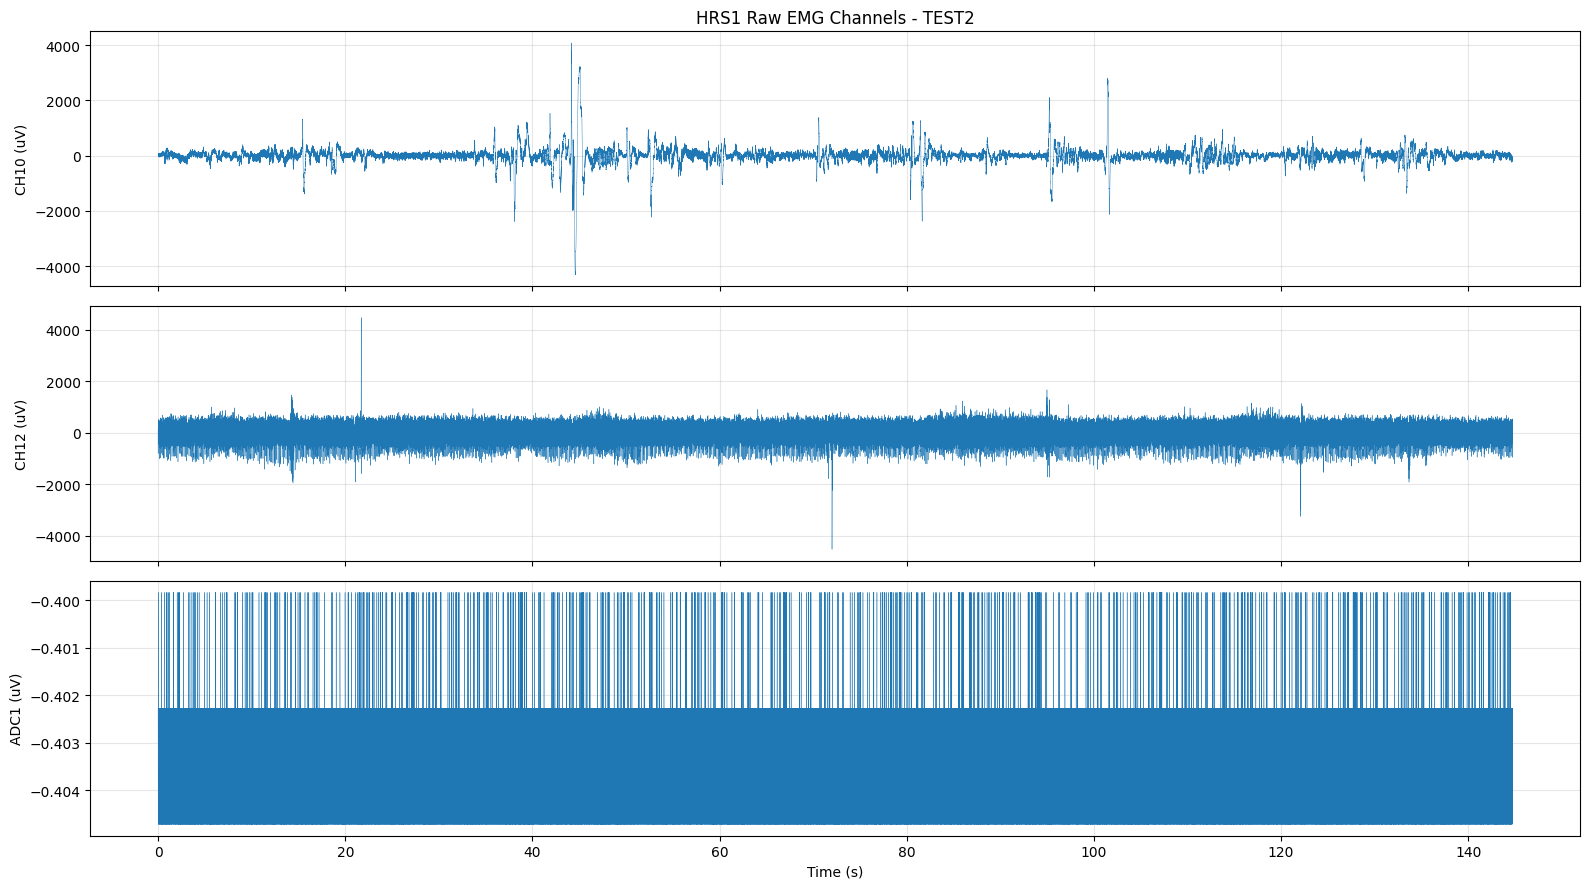

In [55]:
# ---- Plot HRS1: Raw EMG Channels (per-channel overlay) ----
if len(hrs1_emg_blocks) > 0 and len(hrs1_emg_blocks[0].raw_channels) >= 2:
    n_ch = len(hrs1_emg_blocks[0].raw_channels)
    ch_names = hrs1_emg_blocks[0].channel_names if hrs1_emg_blocks[0].channel_names else [f'Ch{i}' for i in range(n_ch)]

    fig, axes = plt.subplots(n_ch, 1, figsize=(16, 3 * n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]

    for ch_idx in range(n_ch):
        ch_data = np.concatenate([b.raw_channels[ch_idx] for b in hrs1_emg_blocks if len(b.raw_channels) > ch_idx])
        t_ch = np.arange(len(ch_data)) / SAMPLE_RATE
        axes[ch_idx].plot(t_ch, ch_data, linewidth=0.3)
        axes[ch_idx].set_ylabel(f'{ch_names[ch_idx]} (uV)')
        axes[ch_idx].grid(True, alpha=0.3)

    axes[0].set_title(f'HRS1 Raw EMG Channels - {hrs1_header.subject_id}')
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()
else:
    print("No raw channel data available.")

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [56]:
# ---- Read the HRS2 file (auto-detected) ----
hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)

print(f"=== HRS2 Header ===")
print(f"  File:               {os.path.basename(hrs2_path)}")
print(f"  File version:       {hrs2_header.file_version}  "
      f"({'includes ADC sync_data' if hrs2_header.file_version >= 1 else 'no ADC sync_data -- version 0'})")
print(f"  Subject ID:         {hrs2_header.subject_id}")
print(f"  Session start time: {hrs2_header.session_start_time}")
print(f"  Stage name:         {hrs2_header.stage_name}")
print(f"  Stage description:  {hrs2_header.stage_description}")
print(f"  Stage type:         {hrs2_header.stage_type}")
print(f"\n  Trials found:       {len(hrs2_trials)}")
print(f"  EMG data blocks:    {len(hrs2_emg_blocks)}")

if len(hrs2_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs2_trials[0]
    print(f"  Start time:         {t0.start_time}")
    print(f"  Min init threshold: {t0.min_initiation_threshold:.4f} uV")
    print(f"  Max init threshold: {t0.max_initiation_threshold:.4f} uV")
    print(f"  Stim amplitude:     {t0.stimulation_amplitude_ma:.4f} mA")
    print(f"  Trial data:         {len(t0.trial_data)} samples ({len(t0.trial_data)*MS_PER_SAMPLE:.1f} ms)")
    has_sync = len(t0.sync_data) > 1
    print(f"  ADC sync data:      {len(t0.sync_data)} samples {'(present)' if has_sync else '(empty -- file_version 0)'}")

    stim_amps = [t.stimulation_amplitude_ma for t in hrs2_trials]
    unique_amps = sorted(set([round(a, 2) for a in stim_amps]))
    print(f"\n=== Stimulation Summary ===")
    print(f"  Unique amplitudes (mA): {unique_amps}")
    print(f"  Total trials:           {len(hrs2_trials)}")
    for amp in unique_amps:
        count = sum(1 for a in stim_amps if round(a, 2) == amp)
        print(f"    {amp:.2f} mA : {count} trial(s)")
else:
    print("\nNo trials found.")

if len(hrs2_emg_blocks) > 0:
    b0 = hrs2_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:  {b0.channel_names}")
    print(f"  Raw channels:   {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
    print(f"  Diff samples:   {len(b0.diff)}")


=== HRS2 Header ===
  File:               TEST2_20260316T164509.hrs2
  File version:       1  (includes ADC sync_data)
  Subject ID:         TEST2
  Session start time: 2026-03-16 16:45:09.612548
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       67
  EMG data blocks:    10706

=== First Trial ===
  Start time:         2026-03-16 16:45:11.651050
  Min init threshold: 78.1744 uV
  Max init threshold: 119.9595 uV
  Stim amplitude:     0.4000 mA
  Trial data:         863 samples (172.6 ms)
  ADC sync data:      863 samples (present)

=== Stimulation Summary ===
  Unique amplitudes (mA): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
  Total trials:           67
    0.00 mA : 3 trial(s)
    0.10 mA : 3 trial(s)
    0.20 mA : 4 trial(s)
    0.30 mA : 3 trial(s)
    0.40 mA : 3 trial(s)
    0.50 mA : 4 trial(s)
    0.60 mA : 3 trial(s)
    0.70 mA : 3 trial(s)
    0.80 m

In [ ]:
# ---- Plot HRS2: Interactive Trial Viewer ----
# Paged 2x3 grid with per-trial zoom and ADC sync overlay toggle.
# Requires an interactive Jupyter kernel (ipywidgets).

from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label, ToggleButton

# ── Configuration ─────────────────────────────────────────────────────────────
PRE_PLOT_MS  = 20.0   # ms before stim onset to display
POST_PLOT_MS = 30.0   # ms after  stim onset to display
N_PER_PAGE   = 6      # trials shown per page (2 rows x 3 cols)

# ── Build plot-ready list (uses get_trial_window from helpers) ───────────
trial_plot_data = []
for _i, _tr in enumerate(hrs2_trials):
    _t, _emg, _adc, _end = get_trial_window(_tr, PRE_PLOT_MS, POST_PLOT_MS)
    trial_plot_data.append({
        'idx': _i, 'trial': _tr,
        't_ms': _t, 'emg': _emg, 'adc': _adc,
        'stim_end_ms': _end,
        'amp': _tr.stimulation_amplitude_ma,
    })

if len(trial_plot_data) == 0:
    print("No HRS2 trials to display.")
else:
    #  Shared EMG y-limits
    _all_emg = np.concatenate([d['emg'] for d in trial_plot_data])
    _lo, _hi = float(np.nanmin(_all_emg)), float(np.nanmax(_all_emg))
    _pad = max(0.08 * (_hi - _lo), 1.0)
    shared_ylim = (_lo - _pad, _hi + _pad)

    #  Pages
    pages = [trial_plot_data[i:i+N_PER_PAGE]
             for i in range(0, len(trial_plot_data), N_PER_PAGE)]
    current_page = {'idx': 0}
    show_adc     = {'val': True}

    out = Output()
    trial_dropdown = Dropdown(description='Trial:')

    #  Core draw helper
    def _draw_trial(ax, d, adc_on, small=True):
        """Render one trial into ax. Returns secondary ADC axis or None."""
        lw   = 1.0 if small else 1.8
        fsz  = 8   if small else 11
        t, emg, adc, end_ms = d['t_ms'], d['emg'], d['adc'], d['stim_end_ms']

        ax.plot(t, emg, color='black', linewidth=lw)
        h_onset = ax.axvline(0, color='blue', linestyle='--', linewidth=lw,
                             label='Stim onset')
        ax.set_xlim(-PRE_PLOT_MS, POST_PLOT_MS)
        ax.set_xlabel('Time (ms)', fontsize=fsz)
        ax.set_ylabel('EMG (µV)',  fontsize=fsz)
        ax.tick_params(labelsize=fsz - 1)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(shared_ylim)

        legend_h = [h_onset]
        legend_l = ['Stim onset']

        if end_ms is not None:
            h_end = ax.axvline(end_ms, color='purple', linestyle='--', linewidth=lw,
                               label=f'Stim end ({end_ms:.1f} ms)')
            legend_h.append(h_end)
            legend_l.append(f'Stim end ({end_ms:.1f} ms)')

        ax_adc = None
        if adc_on and adc is not None:
            ax_adc = ax.twinx()
            h_adc, = ax_adc.plot(t, adc, color='green', linewidth=lw * 0.7,
                                 alpha=0.85, label='ADC (V)')
            ax_adc.set_ylabel('ADC (V)', color='green', fontsize=fsz - 1)
            ax_adc.tick_params(axis='y', labelcolor='green', labelsize=fsz - 2)
            legend_h.append(h_adc)
            legend_l.append('ADC (V)')

        ax.legend(legend_h, legend_l, fontsize=fsz - 2, loc='upper right')
        return ax_adc

    #  Grid page renderer
    def plot_page(page_idx):
        with out:
            out.clear_output(wait=True)
            page = pages[page_idx]
            n    = len(page)

            trial_dropdown.options = [
                (f"Trial {d['idx']+1}  |  {d['amp']:.2f} mA", d['idx'])
                for d in page
            ]
            if trial_dropdown.options:
                trial_dropdown.value = page[0]['idx']

            fig, axs = plt.subplots(2, 3, figsize=(15, 7))
            axs_flat = axs.flatten()

            for j in range(N_PER_PAGE):
                ax = axs_flat[j]
                if j < n:
                    d = page[j]
                    _draw_trial(ax, d, show_adc['val'], small=True)
                    ax.set_title(f"Trial {d['idx']+1}  |  {d['amp']:.2f} mA", fontsize=9)
                else:
                    ax.axis('off')

            n_shown_start = N_PER_PAGE * page_idx + 1
            n_shown_end   = min(N_PER_PAGE * (page_idx + 1), len(trial_plot_data))
            fig.suptitle(
                f"{hrs2_header.subject_id}    "
                f"Trials {n_shown_start}–{n_shown_end} of {len(trial_plot_data)}"
                f"  (Page {page_idx+1}/{len(pages)})",
                fontsize=11
            )
            plt.tight_layout()
            plt.show()

            try:
                def _on_click(event):
                    if event.inaxes is None:
                        return
                    for k, ax in enumerate(axs_flat):
                        if event.inaxes is ax and k < n:
                            if getattr(event, 'dblclick', False):
                                show_zoom(page[k]['idx'])
                            else:
                                trial_dropdown.value = page[k]['idx']
                            break
                fig.canvas.mpl_connect('button_press_event', _on_click)
            except Exception:
                pass

    #  Single-trial zoom renderer
    def show_zoom(trial_idx):
        d = trial_plot_data[trial_idx]
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(13, 5))
            _draw_trial(ax, d, show_adc['val'], small=False)
            ax.set_title(
                f"Trial {d['idx']+1}  |  Stim = {d['amp']:.2f} mA  |  "
                f"{hrs2_header.subject_id}  "
                f"({hrs2_header.session_start_time:%Y-%m-%d %H:%M})",
                fontsize=11
            )
            plt.tight_layout()
            plt.show()

            back_btn = Button(description='Back to grid', button_style='info')
            back_btn.on_click(lambda b: plot_page(current_page['idx']))
            display(back_btn)

    #  Navigation callbacks
    def on_prev(b):
        if current_page['idx'] > 0:
            current_page['idx'] -= 1
            page_drop.value = current_page['idx']
            plot_page(current_page['idx'])

    def on_next(b):
        if current_page['idx'] < len(pages) - 1:
            current_page['idx'] += 1
            page_drop.value = current_page['idx']
            plot_page(current_page['idx'])

    def on_page_change(change):
        if change['name'] == 'value' and change['new'] != current_page['idx']:
            current_page['idx'] = change['new']
            plot_page(current_page['idx'])

    def on_view(b):
        try:
            show_zoom(int(trial_dropdown.value))
        except Exception as e:
            print(f'Could not zoom trial: {e}')

    def on_adc_toggle(change):
        show_adc['val'] = bool(change['new'])
        plot_page(current_page['idx'])

    #  Build controls
    prev_btn   = Button(description='Prev',      button_style='')
    next_btn   = Button(description='Next',      button_style='primary')
    page_drop  = Dropdown(
        options=[(f'Page {i+1}', i) for i in range(len(pages))],
        description='Page:', layout={'width': '130px'}
    )
    view_btn   = Button(description='View trial',  button_style='info')
    adc_toggle = ToggleButton(
        value=True, description='ADC overlay',
        button_style='success',
        tooltip='Show/hide ADC sync line on all plots'
    )

    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)
    page_drop.observe(on_page_change, names='value')
    view_btn.on_click(on_view)
    adc_toggle.observe(on_adc_toggle, names='value')

    controls = HBox([
        prev_btn, next_btn, page_drop,
        Label('  '), trial_dropdown, view_btn,
        Label('  '), adc_toggle
    ])

    print(f"Loaded {len(trial_plot_data)} trials across {len(pages)} page(s).")
    print(f"Shared EMG y-axis: [{shared_ylim[0]:.1f}, {shared_ylim[1]:.1f}] µV")
    print("Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.")

    display(VBox([controls, out]))
    plot_page(0)


Loaded 67 trials across 12 page(s).
Shared EMG y-axis: [-10466.5, 5189.6] µV
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


Trial 60 | Stim: 0.40 mA
  t_ms:     250 samples, [-20.0, 29.8] ms
  emg:      [-228.10, 211.15] uV
  adc:      [0.402, 0.405] V
  stim_end: 0.0 ms


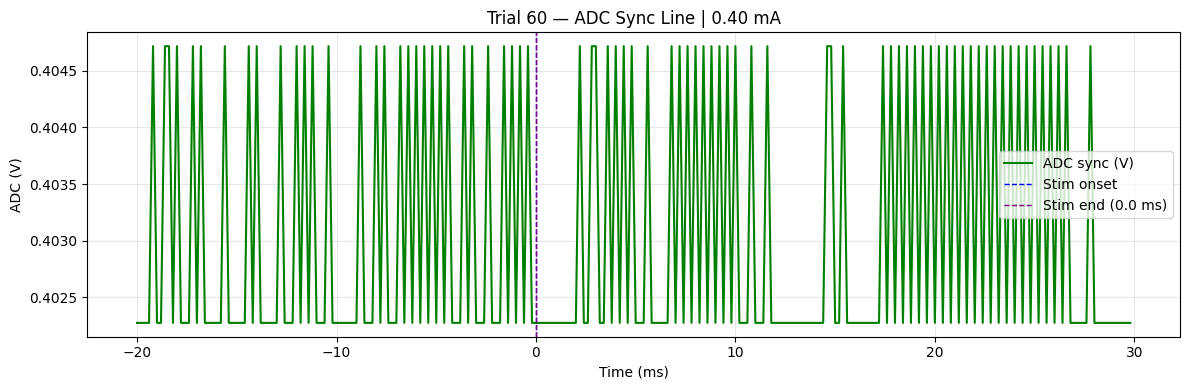

In [61]:
# Debug: ADC sync line for trial 60 using get_trial_window
TRIAL_IDX = 59  # 0-indexed (trial 60)

trial_60 = hrs2_trials[TRIAL_IDX]
t_ms, emg, adc, stim_end_ms = get_trial_window(trial_60, PRE_PLOT_MS, POST_PLOT_MS)

print(f"Trial {TRIAL_IDX+1} | Stim: {trial_60.stimulation_amplitude_ma:.2f} mA")
print(f"  t_ms:     {len(t_ms)} samples, [{t_ms[0]:.1f}, {t_ms[-1]:.1f}] ms")
print(f"  emg:      [{emg.min():.2f}, {emg.max():.2f}] uV")
print(f"  adc:      [{adc.min():.3f}, {adc.max():.3f}] V")
print(f"  stim_end: {stim_end_ms} ms")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_ms, adc, color='green', linewidth=1.5, label='ADC sync (V)')
ax.axvline(0, color='blue', linestyle='--', linewidth=1, label='Stim onset')
if stim_end_ms is not None:
    ax.axvline(stim_end_ms, color='purple', linestyle='--', linewidth=1, label=f'Stim end ({stim_end_ms:.1f} ms)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('ADC (V)')
ax.set_title(f'Trial {TRIAL_IDX+1} — ADC Sync Line | {trial_60.stimulation_amplitude_ma:.2f} mA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ---- Failed Trial Detector ----
# For file_version >= 2, onset detection results are read directly from the pre-computed
# fields stored in each trial object (onset_detected, sync_peak_voltage, etc.).
# For older files, the fields are derived here from sync_data.

def classify_trials(trials, file_version=0,
                    bin_samples=BIN_SAMPLES, record_samples=TRIAL_RECORD_SAMPLES,
                    onset_threshold=STIM_ONSET_THRESHOLD, end_threshold=STIM_END_THRESHOLD):
    """
    Scan all MhRecTrial objects and return a list of dicts describing each trial's
    ADC-sync quality.

    For file_version >= 2, pre-computed fields on each trial are used directly.
    For file_version < 2, onset detection is re-derived from sync_data.

    Keys in each returned dict:
        idx                          – 0-based trial index
        amp_ma                       – stimulation amplitude (mA)
        has_sync                     – sync_data present (file_version >= 1)
        onset_found                  – True if a real rising edge was detected
        onset_idx                    – sample index used for onset
        adc_peak                     – max ADC value in the onset search window
        adc_noise_std                – std of ADC pre-stim baseline
        stim_end_ms                  – ms after onset where ADC dropped (or None)
        stim_duration_ms             – pulse duration in ms (0 if end not found)
        n_pre_trigger_frames_discarded – queued frames discarded (v2 only, else 0)
        first_post_trigger_frame_sample_id – OE sample counter of first RECORD frame
        failed                       – True when onset_found is False
    """
    search_start = int(bin_samples * 0.6)
    results = []

    for i, tr in enumerate(trials):
        has_sync = len(tr.sync_data) > 1
        rec = {'idx': i, 'amp_ma': tr.stimulation_amplitude_ma, 'has_sync': has_sync}

        if not has_sync:
            rec.update(onset_found=False, onset_idx=bin_samples,
                       adc_peak=float('nan'), adc_noise_std=float('nan'),
                       stim_end_ms=None, stim_duration_ms=0.0,
                       n_pre_trigger_frames_discarded=0,
                       first_post_trigger_frame_sample_id=0,
                       failed=True)
            results.append(rec)
            continue

        if file_version >= 2:
            # --- Use pre-computed fields written by the app ---
            onset_found = bool(tr.onset_detected)
            onset_idx   = tr.onset_sample_index if onset_found else bin_samples
            adc_peak    = float(tr.sync_peak_voltage)
            stim_end_ms = (float(tr.stim_duration_ms)
                           if tr.stim_end_sample_index >= 0 else None)
            stim_dur_ms = float(tr.stim_duration_ms)
            n_disc      = int(tr.n_pre_trigger_frames_discarded)
            first_sid   = int(tr.first_post_trigger_frame_sample_id)
        else:
            # --- Derive from raw sync_data (file_version 0 or 1) ---
            sd = np.asarray(tr.sync_data, dtype=float)
            search_end = min(bin_samples + record_samples, len(sd))
            window = sd[search_start:search_end]
            cands  = np.where(window >= onset_threshold)[0]
            if len(cands) > 0:
                onset_idx   = search_start + int(cands[0])
                onset_found = True
            else:
                onset_idx   = bin_samples
                onset_found = False
            adc_peak    = float(window.max()) if len(window) > 0 else float('nan')
            stim_end_ms = None
            stim_dur_ms = 0.0
            if onset_idx < len(sd):
                ends = np.where(sd[onset_idx:] < end_threshold)[0]
                if len(ends) > 0:
                    stim_end_ms = float(ends[0]) * MS_PER_SAMPLE
                    stim_dur_ms = stim_end_ms
            n_disc    = 0
            first_sid = 0

        # Noise: std of ADC in the first 60% of the pre-stim window
        sd_for_noise = np.asarray(tr.sync_data, dtype=float)
        pre_window = sd_for_noise[:search_start]
        adc_noise_std = float(pre_window.std()) if len(pre_window) > 0 else float('nan')

        rec.update(onset_found=onset_found, onset_idx=onset_idx,
                   adc_peak=adc_peak, adc_noise_std=adc_noise_std,
                   stim_end_ms=stim_end_ms, stim_duration_ms=stim_dur_ms,
                   n_pre_trigger_frames_discarded=n_disc,
                   first_post_trigger_frame_sample_id=first_sid,
                   failed=not onset_found)
        results.append(rec)
    return results


trial_report = classify_trials(hrs2_trials, file_version=hrs2_header.file_version)

failed = [r for r in trial_report if r['failed']]
passed = [r for r in trial_report if not r['failed']]

print(f"File version : {hrs2_header.file_version}  "
      f"({'pre-computed fields used' if hrs2_header.file_version >= 2 else 'fields derived from sync_data'})")
print(f"Total trials : {len(trial_report)}")
print(f"Passed       : {len(passed)}")
print(f"Failed       : {len(failed)}")
print()

if failed:
    v2 = hrs2_header.file_version >= 2
    hdr = (f"{'Trial':>6}  {'Amp':>6}  {'ADC peak':>9}  {'Noise std':>10}  "
           f"{'Stim dur ms':>11}  {'Discarded':>9}  Reason")
    print(hdr)
    print("-" * len(hdr))
    for r in failed:
        reason = ("no sync data" if not r['has_sync']
                  else f"ADC peak {r['adc_peak']:.3f} V < {STIM_ONSET_THRESHOLD} V threshold")
        dur_str  = f"{r['stim_duration_ms']:.2f}" if r['stim_duration_ms'] else "—"
        disc_str = str(r['n_pre_trigger_frames_discarded']) if v2 else "n/a"
        print(f"{r['idx']+1:>6}  {r['amp_ma']:>6.2f}  {r['adc_peak']:>9.3f}  "
              f"{r['adc_noise_std']:>10.4f}  {dur_str:>11}  {disc_str:>9}  {reason}")
else:
    print("No failed trials detected.")


In [ ]:
# ---- Plot Failed Trials (ADC + EMG overview) ----
# Shows every failed trial in a grid so you can visually confirm the classification.

if not failed:
    print("No failed trials to plot.")
else:
    N_COLS = 3
    n_fail = len(failed)
    n_rows = int(np.ceil(n_fail / N_COLS))
    v2 = hrs2_header.file_version >= 2

    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(15, 4 * n_rows))
    axes = np.array(axes).flatten()

    for j, r in enumerate(failed):
        ax = axes[j]
        tr = hrs2_trials[r['idx']]
        t_ms, emg, adc, stim_end_ms = get_trial_window(tr, PRE_PLOT_MS, POST_PLOT_MS)

        ax.plot(t_ms, emg, color='black', linewidth=0.8, label='EMG')
        ax.axvline(0, color='blue', linestyle='--', linewidth=1, label='Onset (fallback)')
        ax.set_ylabel('EMG (µV)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

        if adc is not None:
            ax2 = ax.twinx()
            ax2.plot(t_ms, adc, color='green', linewidth=0.8, alpha=0.85, label='ADC (V)')
            ax2.axhline(STIM_ONSET_THRESHOLD, color='red', linestyle=':', linewidth=0.8,
                        label=f'Onset thresh {STIM_ONSET_THRESHOLD} V')
            ax2.set_ylabel('ADC (V)', color='green', fontsize=7)
            ax2.tick_params(axis='y', labelcolor='green', labelsize=7)

        if stim_end_ms is not None:
            ax.axvline(stim_end_ms, color='purple', linestyle='--', linewidth=1,
                       label=f'End {stim_end_ms:.1f} ms')

        peak_str = f"pk={r['adc_peak']:.3f}V" if not np.isnan(r['adc_peak']) else "no sync"
        disc_str = f"  disc={r['n_pre_trigger_frames_discarded']}" if v2 else ""
        ax.set_title(
            f"Trial {r['idx']+1}  {r['amp_ma']:.2f}mA  [{peak_str}{disc_str}]",
            fontsize=8
        )
        ax.set_xlabel('Time (ms)', fontsize=7)
        ax.set_xlim(-PRE_PLOT_MS, POST_PLOT_MS)

    for k in range(n_fail, len(axes)):
        axes[k].axis('off')

    v_label = f"v{hrs2_header.file_version}"
    fig.suptitle(
        f"Failed trials ({n_fail}/{len(trial_report)})  —  "
        f"{hrs2_header.subject_id}  [{v_label}]",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    # For version-2 files: print the frame-timing latency summary for each failed trial
    if v2:
        print("\nFrame timing latency for failed trials (ms after trigger):")
        for r in failed:
            tr = hrs2_trials[r['idx']]
            tw = tr.trigger_wall_time_ms
            if tw > 0 and len(tr.frame_received_timestamps_ms) > 0:
                latencies = (tr.frame_received_timestamps_ms.astype(float) - float(tw))
                print(f"  Trial {r['idx']+1}: {len(latencies)} frames, "
                      f"first={latencies[0]:.1f} ms, last={latencies[-1]:.1f} ms  "
                      f"| OE sample id={tr.first_post_trigger_frame_sample_id}")
            else:
                print(f"  Trial {r['idx']+1}: no timing data")


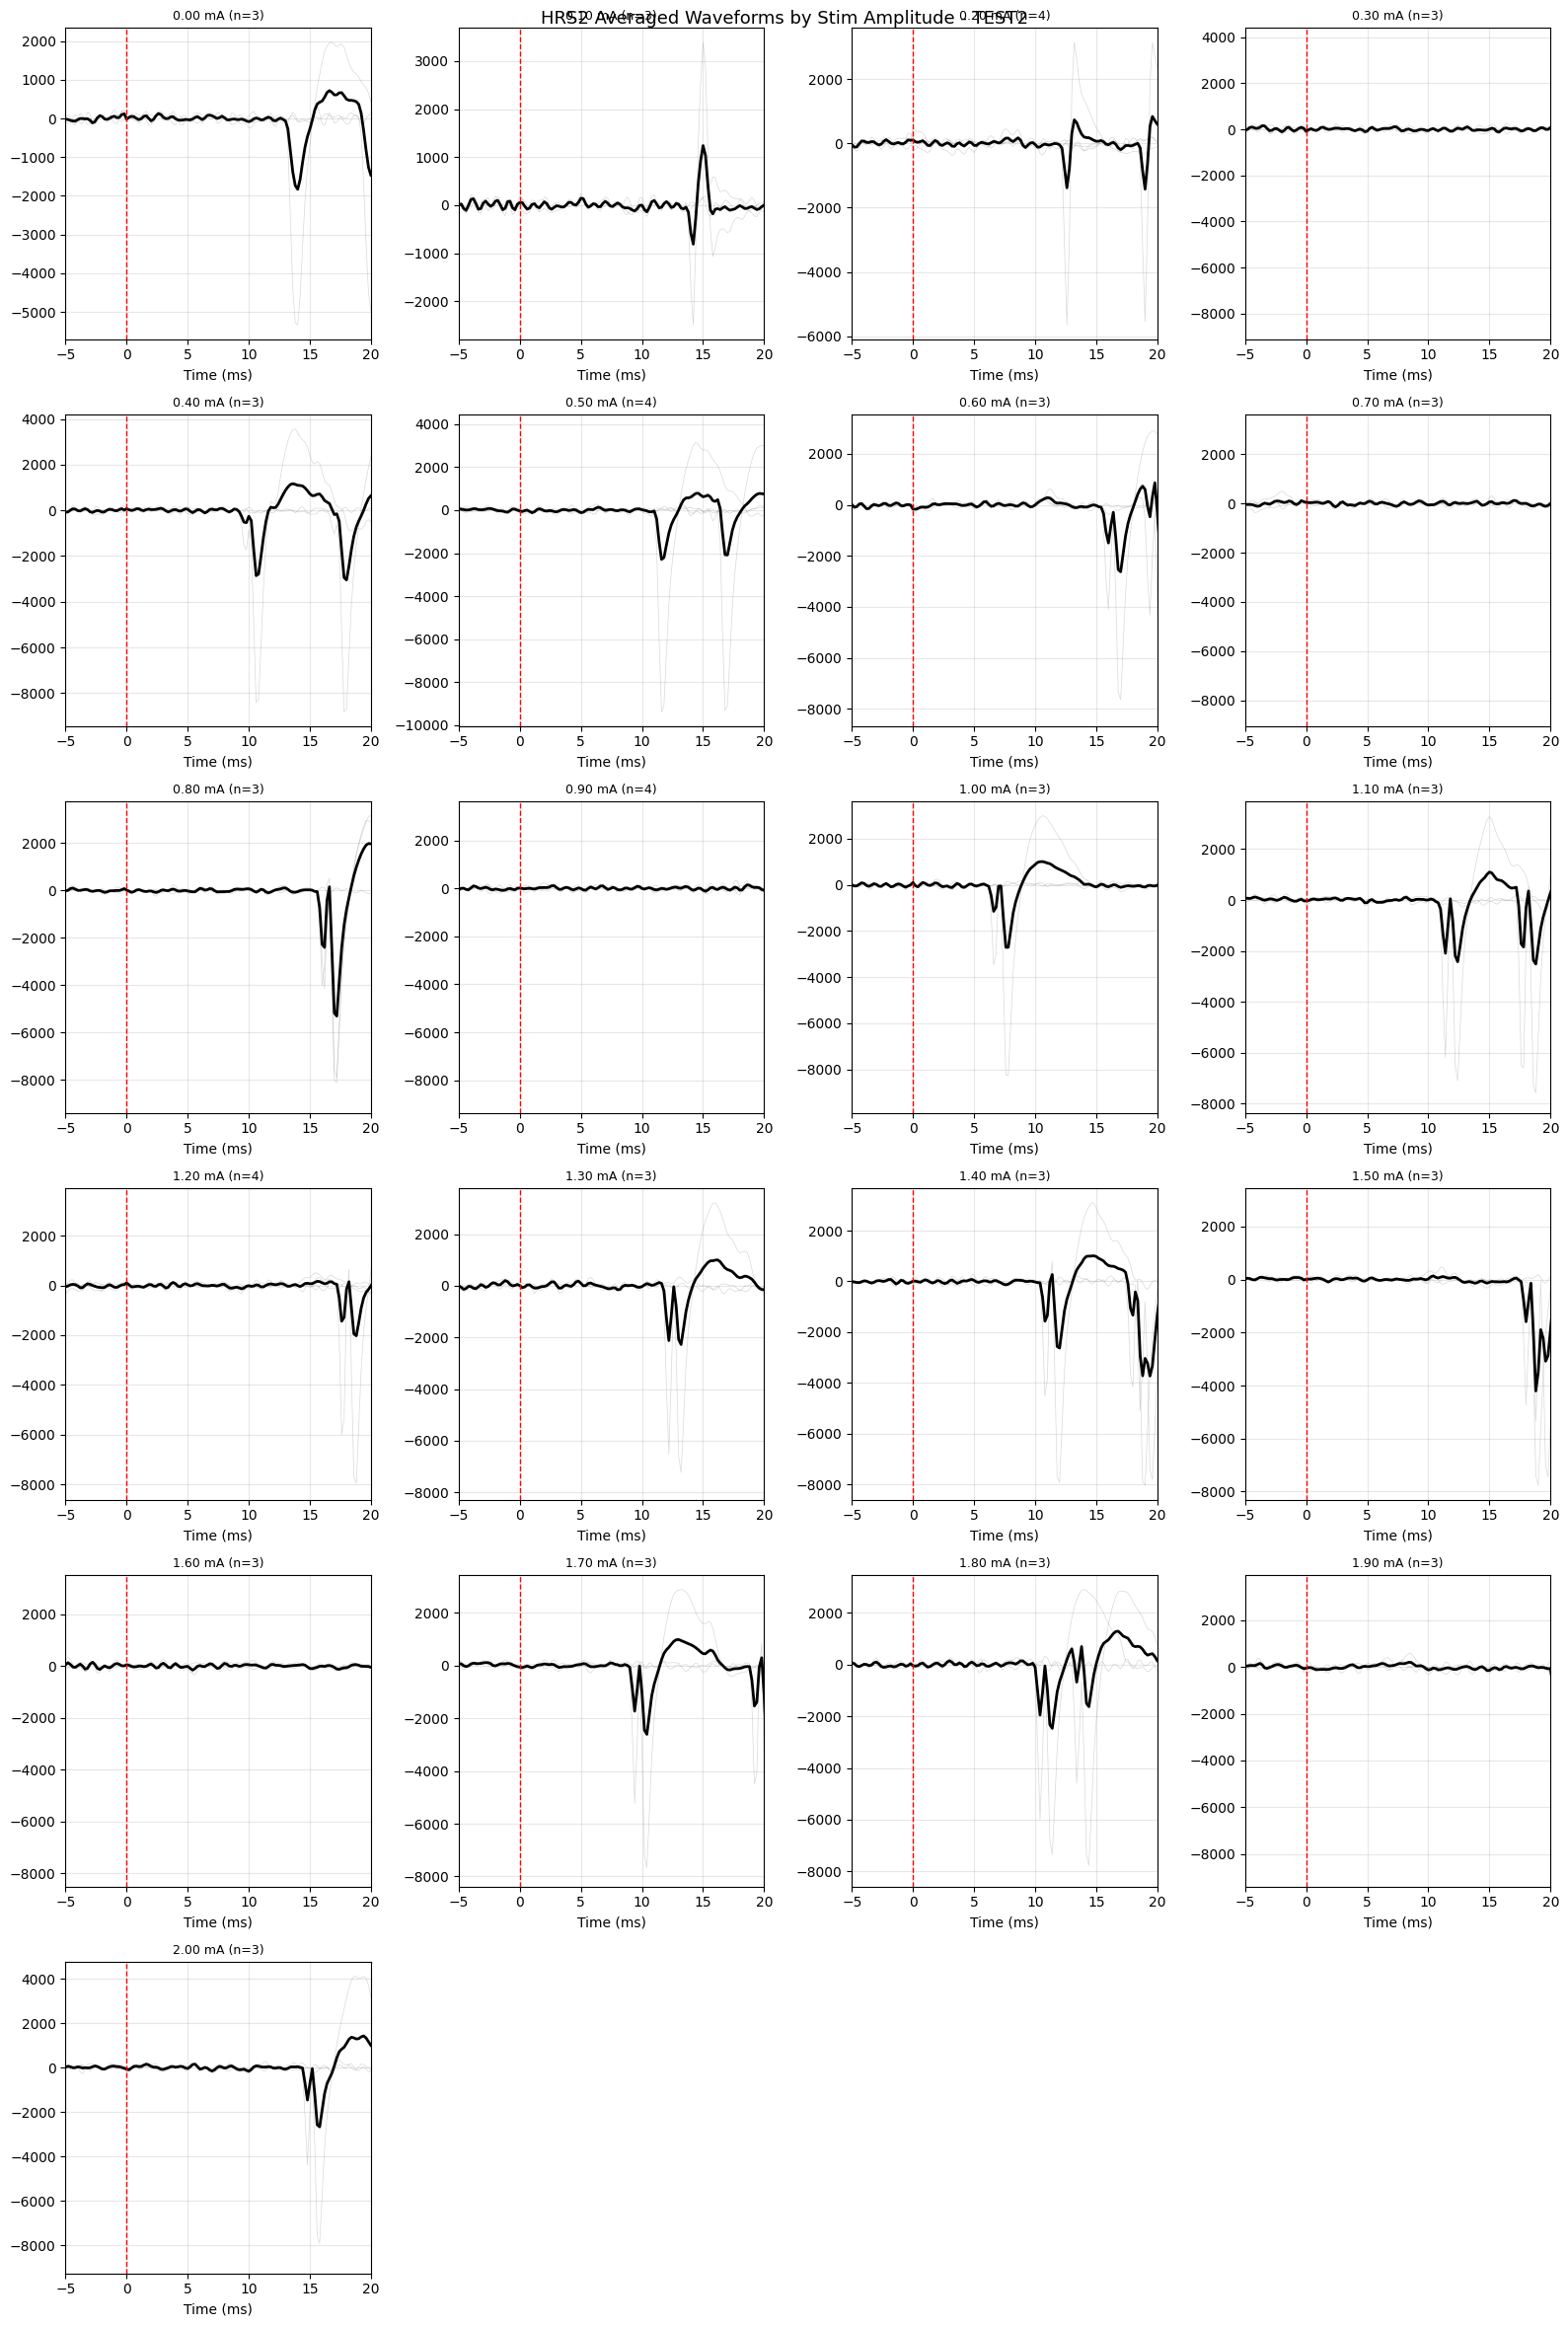

In [58]:
# ---- Plot HRS2: Averaged Waveforms Grouped by Stimulation Amplitude ----
from collections import defaultdict

if len(hrs2_trials) > 0:
    # Group trials by stim amplitude
    groups = defaultdict(list)
    for trial in hrs2_trials:
        key = round(trial.stimulation_amplitude_ma, 2)
        groups[key].append(trial.trial_data)

    sorted_amps = sorted(groups.keys())
    n_groups = len(sorted_amps)
    n_cols = 4
    n_rows = int(np.ceil(n_groups / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).flatten()

    for idx, amp in enumerate(sorted_amps):
        ax = axes[idx]
        waveforms = groups[amp]

        # Pad/truncate to common length
        max_len = max(len(w) for w in waveforms)
        padded = np.full((len(waveforms), max_len), np.nan)
        for k, w in enumerate(waveforms):
            padded[k, :len(w)] = w

        t_ms = (np.arange(max_len) - BIN_SAMPLES) * MS_PER_SAMPLE
        avg = np.nanmean(padded, axis=0)

        # Plot individual traces faintly
        for row in padded:
            ax.plot(t_ms, row, color='gray', alpha=0.3, linewidth=0.5)

        # Plot average
        ax.plot(t_ms, avg, color='black', linewidth=2)
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f'{amp:.2f} mA (n={len(waveforms)})', fontsize=9)
        ax.set_xlim(-5, 20)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Time (ms)')

    for j in range(n_groups, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'HRS2 Averaged Waveforms by Stim Amplitude - {hrs2_header.subject_id}', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No HRS2 trials to group.")

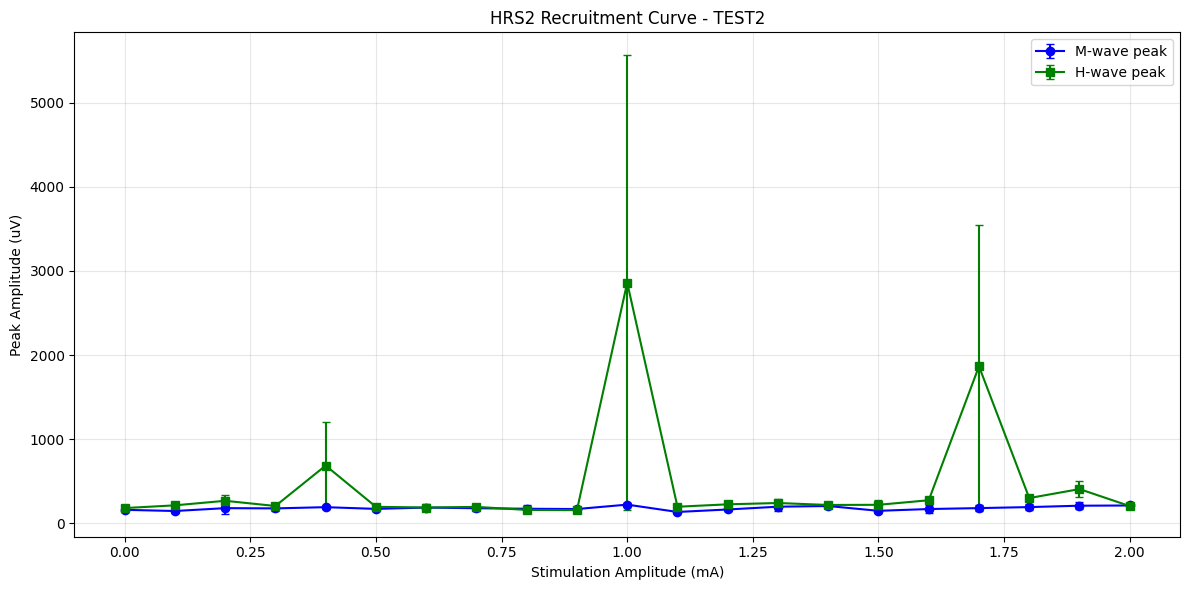

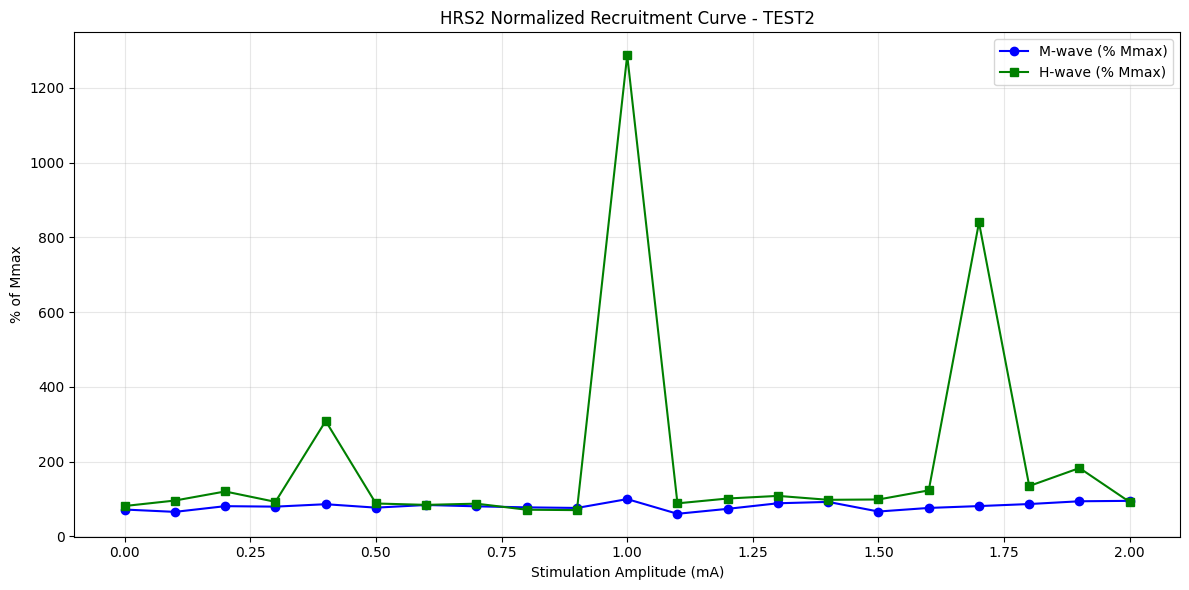

M_max = 222.13 uV
H_max = 2859.35 uV (1287.2% of M_max)


In [59]:
# ---- Plot HRS2: Recruitment Curve (M-wave and H-wave peak amplitudes) ----
# M-wave window: ~1.5-4 ms post-stim, H-wave window: ~4.5-10 ms post-stim

M_WAVE_START_MS = 1.5
M_WAVE_END_MS = 4.0
H_WAVE_START_MS = 4.5
H_WAVE_END_MS = 10.0

if len(hrs2_trials) > 0:
    m_peaks_by_amp = defaultdict(list)
    h_peaks_by_amp = defaultdict(list)

    for trial in hrs2_trials:
        data = trial.trial_data
        t_ms = (np.arange(len(data)) - BIN_SAMPLES) * MS_PER_SAMPLE
        amp_key = round(trial.stimulation_amplitude_ma, 2)

        # M-wave peak
        m_mask = (t_ms >= M_WAVE_START_MS) & (t_ms <= M_WAVE_END_MS)
        if np.any(m_mask):
            m_peaks_by_amp[amp_key].append(np.max(np.abs(data[m_mask])))

        # H-wave peak
        h_mask = (t_ms >= H_WAVE_START_MS) & (t_ms <= H_WAVE_END_MS)
        if np.any(h_mask):
            h_peaks_by_amp[amp_key].append(np.max(np.abs(data[h_mask])))

    rc_amps = sorted(set(m_peaks_by_amp.keys()) | set(h_peaks_by_amp.keys()))
    m_means = np.array([np.mean(m_peaks_by_amp.get(a, [0])) for a in rc_amps])
    h_means = np.array([np.mean(h_peaks_by_amp.get(a, [0])) for a in rc_amps])

    import scipy.stats as stats
    m_sems = np.array([stats.sem(m_peaks_by_amp[a]) if len(m_peaks_by_amp.get(a, [])) > 1 else 0 for a in rc_amps])
    h_sems = np.array([stats.sem(h_peaks_by_amp[a]) if len(h_peaks_by_amp.get(a, [])) > 1 else 0 for a in rc_amps])

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.errorbar(rc_amps, m_means, yerr=m_sems, fmt='o-', color='blue', label='M-wave peak', capsize=3)
    ax.errorbar(rc_amps, h_means, yerr=h_sems, fmt='s-', color='green', label='H-wave peak', capsize=3)
    ax.set_xlabel('Stimulation Amplitude (mA)')
    ax.set_ylabel('Peak Amplitude (uV)')
    ax.set_title(f'HRS2 Recruitment Curve - {hrs2_header.subject_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Normalized recruitment curve
    M_max = np.max(m_means) if np.max(m_means) > 0 else 1
    m_norm = (m_means / M_max) * 100
    h_norm = (h_means / M_max) * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(rc_amps, m_norm, 'o-', color='blue', label='M-wave (% Mmax)')
    ax.plot(rc_amps, h_norm, 's-', color='green', label='H-wave (% Mmax)')
    ax.set_xlabel('Stimulation Amplitude (mA)')
    ax.set_ylabel('% of Mmax')
    ax.set_title(f'HRS2 Normalized Recruitment Curve - {hrs2_header.subject_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"M_max = {M_max:.2f} uV")
    print(f"H_max = {np.max(h_means):.2f} uV ({np.max(h_norm):.1f}% of M_max)")
else:
    print("No HRS2 trials available for recruitment curve.")

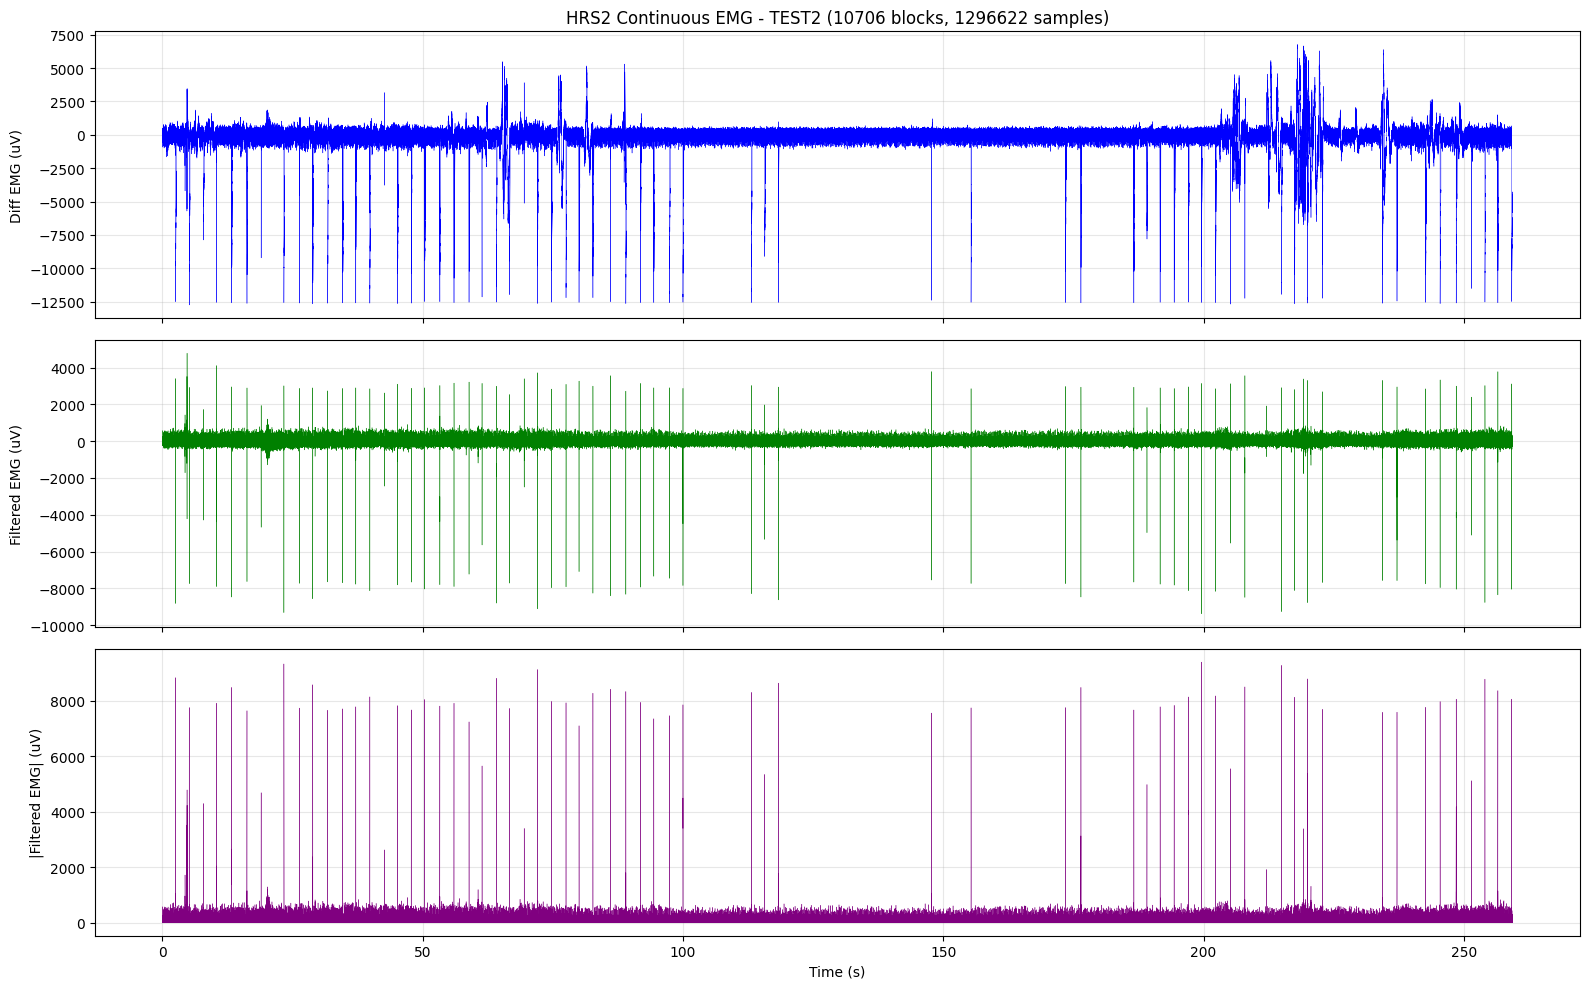

Total continuous samples: 1296622, Duration: 259.3 s


In [60]:
# ---- Plot HRS2: Continuous EMG Data ----
if len(hrs2_emg_blocks) > 0:
    all_diff_s2 = np.concatenate([b.diff for b in hrs2_emg_blocks])
    all_filt_s2 = np.concatenate([b.filtered for b in hrs2_emg_blocks])
    all_abs_s2  = np.concatenate([b.abs_val for b in hrs2_emg_blocks])

    t_s2 = np.arange(len(all_diff_s2)) / SAMPLE_RATE

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_s2, all_diff_s2, color='blue', linewidth=0.3)
    axes[0].set_ylabel('Diff EMG (uV)')
    axes[0].set_title(f'HRS2 Continuous EMG - {hrs2_header.subject_id} ({len(hrs2_emg_blocks)} blocks, {len(all_diff_s2)} samples)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_s2, all_filt_s2, color='green', linewidth=0.3)
    axes[1].set_ylabel('Filtered EMG (uV)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_s2, all_abs_s2, color='purple', linewidth=0.3)
    axes[2].set_ylabel('|Filtered EMG| (uV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Total continuous samples: {len(all_diff_s2)}, Duration: {t_s2[-1]:.1f} s")
else:
    print("No EMG data blocks found in this HRS2 file.")